In [2]:
import numpy as np

In [5]:
rw1=.01 # [m]
rw2=0.02 #[m]
s=1 #[m]
#constantes
mu=4*np.pi*10**(-7)
l=mu/(2*np.pi)*np.log((s-rw2)*(s-rw1)/(rw1*rw2))
print(l)

1.6973880296490434e-06


In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt

def inductancia_por_longitud(r1, r2, D):
    """
    Calcula la inductancia por unidad de longitud (H/m)
    de dos conductores cilíndricos paralelos en aire.
    
    r1, r2 : radios de los conductores [m]
    D      : distancia entre centros [m]
    """
    mu_0 = 4 * math.pi * 1e-7  # Permeabilidad del vacío (H/m)
    
    L = (mu_0 / math.pi) * math.log(D / math.sqrt(r1 * r2))
    #Calculo valor exacto
    L2 = (mu_0 / math.pi/2) * math.log(((D - r1) * (D - r2)) / (r1 * r2))
    return L,L2


# Parámetros del problema
r1 = 0.01   # 1 cm -> m
r2 = 0.02   # 2 cm -> m
D  = 0.1    # 1 m

# Cálculo
Laprox, Lexacto = inductancia_por_longitud(r1, r2, D)

print(f"Inductancia por unidad de longitud: {Laprox:.3e} H/m")
print(f"L_aprox: {Laprox*1e6:.3f} µH/m")
print(f"L_exacto: {Lexacto*1e6:.3f} µH/m")


Inductancia por unidad de longitud: 7.824e-07 H/m
L_aprox: 0.782 µH/m
L_exacto: 0.717 µH/m


In [34]:
# Radios de los conductores (m)
r1 = 0.01   # 1 cm
r2 = 0.01   # 1 cm

# Rango de distancias entre centros (m)
D = np.linspace(0.05, 2.0, 200)  # desde 5 cm hasta 1 m

In [35]:
L_aprox = np.zeros_like(D)
L_exacta = np.zeros_like(D)

for i, d in enumerate(D):
    L_aprox[i], L_exacta[i] = inductancia_por_longitud(r1, r2, d)

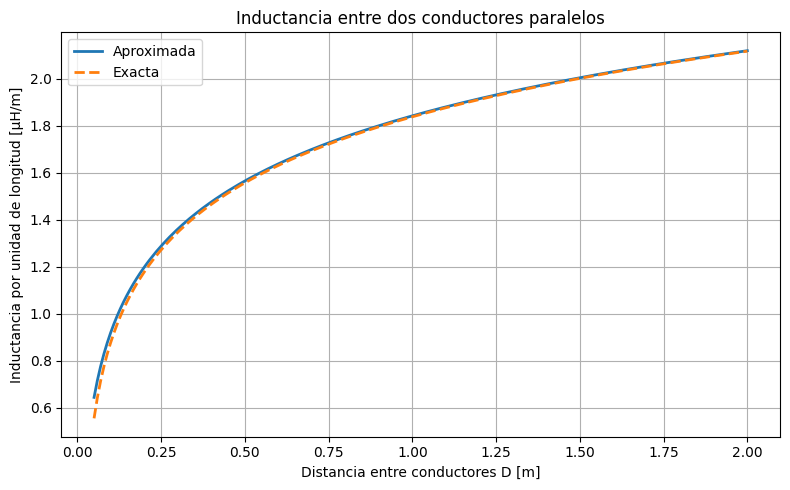

In [36]:
plt.figure(figsize=(8,5))
plt.plot(D, L_aprox * 1e6, label="Aproximada", linewidth=2)
plt.plot(D, L_exacta * 1e6, label="Exacta", linestyle="--", linewidth=2)

plt.xlabel("Distancia entre conductores D [m]")
plt.ylabel("Inductancia por unidad de longitud [µH/m]")
plt.title("Inductancia entre dos conductores paralelos")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
error_abs = np.abs(L_aprox - L_exacta)
error_rel = error_abs / L_exacta

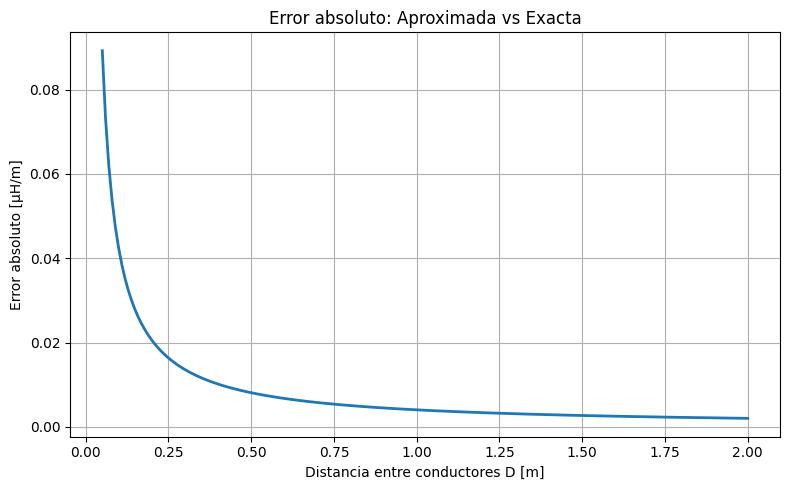

In [38]:
plt.figure(figsize=(8,5))
plt.plot(D, error_abs * 1e6, linewidth=2)

plt.xlabel("Distancia entre conductores D [m]")
plt.ylabel("Error absoluto [µH/m]")
plt.title("Error absoluto: Aproximada vs Exacta")
plt.grid(True)
plt.tight_layout()
plt.show()

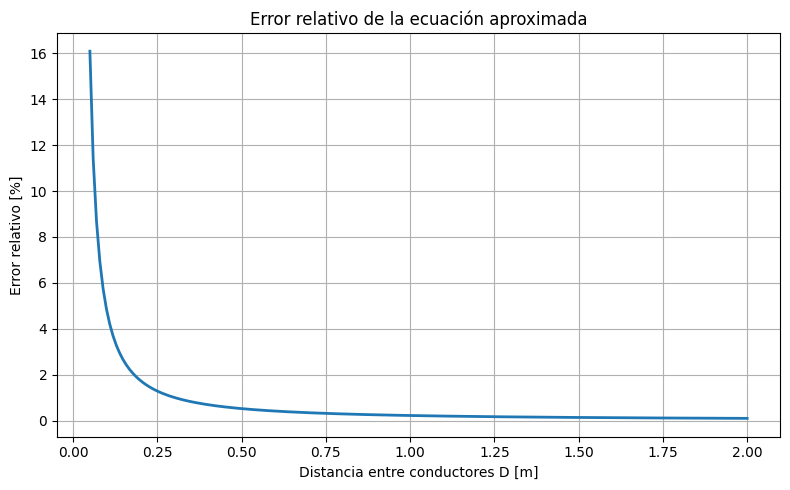

In [39]:
plt.figure(figsize=(8,5))
plt.plot(D, error_rel * 100, linewidth=2)

plt.xlabel("Distancia entre conductores D [m]")
plt.ylabel("Error relativo [%]")
plt.title("Error relativo de la ecuación aproximada")
plt.grid(True)
plt.tight_layout()
plt.show()